In [1]:
from pathlib import Path

import numpy as onp
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
BASERESULTSDIR = Path("example_results/")
QUANTITY = "forces"
ROOTNAMES_TO_LEGEND_LABELS = {
    "msm_rcut-3.0_p-4": "$r_{\mathrm{cut}} = 3 \overline{d}$, $p=4$",
    "msm_rcut-6.0_p-6": "$r_{\mathrm{cut}} = 6 \overline{d}$, $p=6$",
    "exact": "exact",
}

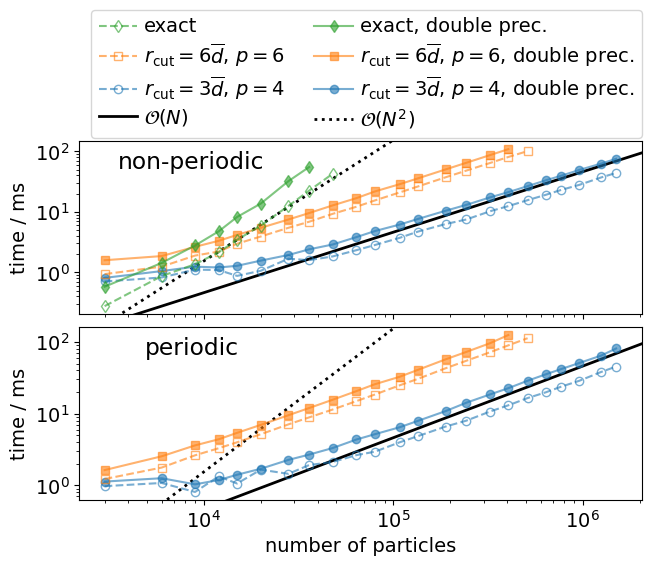

In [3]:
MARKERLIST = ["o", "s", "d"]
plt.rcParams["font.size"] = 14

fig, axs = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(6.4, 5.6),
    layout="constrained",
)
axs[-1].set_xlabel("number of particles")
for ax, pbclabel, title in zip(
    axs, ["nonperiodic", "periodic"], ["non-periodic", "periodic"]
):
    ax.set_title(title, x=0.2, y=1.0, pad=-20)
    ax.set_ylabel("time / ms")
    for rootname, marker in zip(ROOTNAMES_TO_LEGEND_LABELS, MARKERLIST):
        if pbclabel == "periodic" and rootname == "exact":
            # One cannot compute an exact all-pairs reference result in periodic case
            continue
        resultsdirname = pbclabel + "-" + rootname
        label = ROOTNAMES_TO_LEGEND_LABELS[rootname]
        for double_precision, linestyle, facecolor in zip(
            [False, True], ["--", "-"], ["none", None]
        ):
            color = None
            if double_precision:
                resultsdirname += "_doubleprec"
                label += ", double prec."
                color = lns[0].get_color()
            resultsdir = BASERESULTSDIR / resultsdirname
            results = pd.read_csv(resultsdir / "results.csv")
            particle_numbers = results["n_particles"].values
            times = results["time"].values
            lns = ax.plot(
                particle_numbers,
                1e3 * times,
                label=label,
                alpha=0.6,
                color=color,
                marker=marker,
                markerfacecolor=facecolor,
                linestyle=linestyle,
            )

# Reorder legend entries such that the single- and double-precision versions
# of the same algorithm/settings are next to each other on the same line:
reordered_lines = axs[0].get_lines()[1::2] + axs[0].get_lines()[::2]

# Save plots in logarithmic scale
for ax in axs:
    ax.set_xscale("log")
    ax.set_yscale("log")
    original_xlim = ax.get_xlim()
    original_ylim = ax.get_ylim()
    extra_offset_factor = 2.0
    x_0 = min([ln.get_data()[0].min() for ln in reordered_lines])
    y_0 = min([ln.get_data()[1].min() for ln in reordered_lines])
    x = onp.array(original_xlim)
    lines_ref_perfect_scaling = []
    for exponent, linestyle in zip([1, 2], ["-", ":"]):
        alpha = y_0 / x_0**exponent / extra_offset_factor
        if exponent == 1:
            label = f"$\mathcal{{O}}(N)$"
        else:
            label = f"$\mathcal{{O}}(N^{exponent})$"
        lns = ax.plot(
            x,
            alpha * x**exponent,
            color="black",
            zorder=-10,
            # alpha=0.75,
            lw=2.0,
            ls=linestyle,
            label=label,
        )
        lines_ref_perfect_scaling += lns
    ax.set_xlim(original_xlim)
    ax.set_ylim(original_ylim)
legend_handles = (
    [lines_ref_perfect_scaling[1]]
    + reordered_lines[: len(reordered_lines) // 2]
    + [lines_ref_perfect_scaling[0]]
    + reordered_lines[len(reordered_lines) // 2 :]
)
fig.legend(
    ncols=2,
    handles=legend_handles,
    reverse=True,
    labelspacing=0.25,
    columnspacing=1.5,
    handletextpad=0.35,
    loc="outside upper right",
)
filename_without_suffix = f"scaling_{QUANTITY}" + "_loglog"
for suffix in [".png", ".pdf"]:
    fig.savefig(BASERESULTSDIR / (filename_without_suffix + suffix))

plt.show()